<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

### Sistema de predicción de ventas
Queremos predecir las ventas futuras utilizando series temporales. Para ello, emplearemos un modelo ARIMA sobre un conjunto de datos de ventas diarias.
</div>

In [7]:
# CONFIGURACIÓN DEL ENTORNO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Algoritmos Naive Bayes

# Librerías para preprocesamiento y Machine Learning 
import pandas as pd
import numpy as np




from pickle import dump
from pathlib import Path

# Suprimir advertencias
import warnings
warnings.filterwarnings('ignore')

# Establecer estilo de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ ¡Librerías importadas exitosamente!")

✓ ¡Librerías importadas exitosamente!


In [8]:
# Cargar datos preprocesados
df = pd.read_csv('../data/raw/sales.csv')
print(df.head())

                         date      sales
0  2022-09-03 17:10:08.079328  55.292157
1  2022-09-04 17:10:08.079328  53.803211
2  2022-09-05 17:10:08.079328  58.141693
3  2022-09-06 17:10:08.079328  64.530899
4  2022-09-07 17:10:08.079328  66.013633


<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

### Paso 2: Construir y analizar la serie temporal
Construye la estructura de datos válida para la serie temporal, grafícala y luego analízala respondiendo las siguientes preguntas:

¿Cuál es el tenor de la serie temporal?
¿Cuál es la tendencia?
¿Es estacionaria?
¿Hay variabilidad o ruido?
</div>

Período  : 2022-09-03  →  2023-09-03
Frecuencia: <Day>
Registros : 366  |  Nulos: 0
                                sales
date                                 
2022-09-03 17:10:08.079328  55.292157
2022-09-04 17:10:08.079328  53.803211
2022-09-05 17:10:08.079328  58.141693
2022-09-06 17:10:08.079328  64.530899
2022-09-07 17:10:08.079328  66.013633


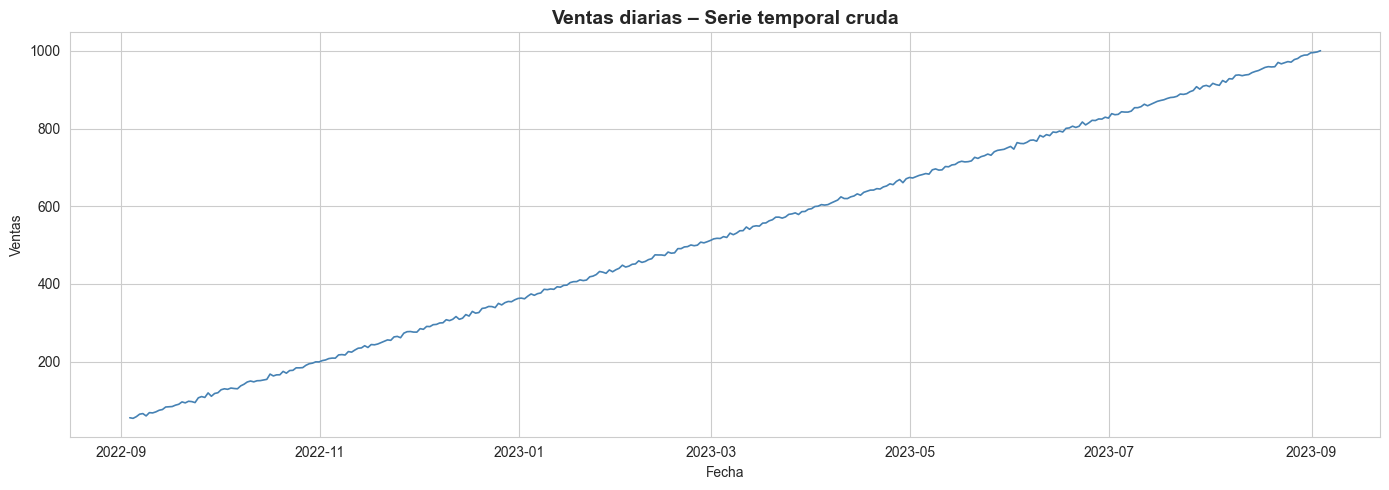

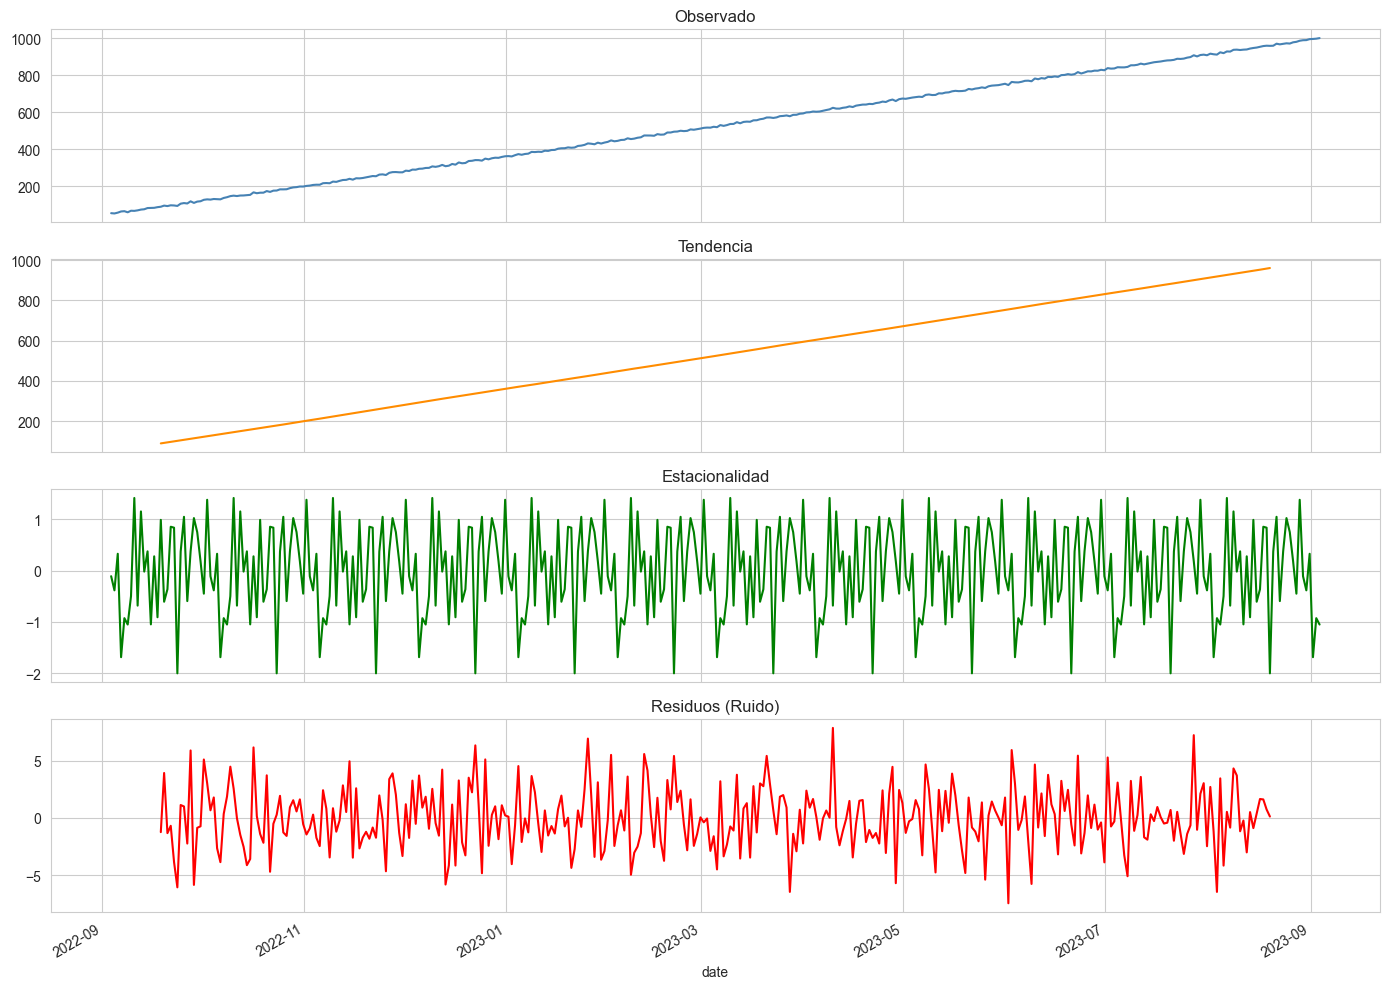


══════════ Prueba de Dickey-Fuller ══════════
  Estadístico ADF : 0.5454
  Valor p         : 0.986190
  Crítico  1%     : -3.4491
  Crítico  5%     : -2.8698
  Crítico 10%     : -2.5712

  → La serie NO es estacionaria (α = 0.05)


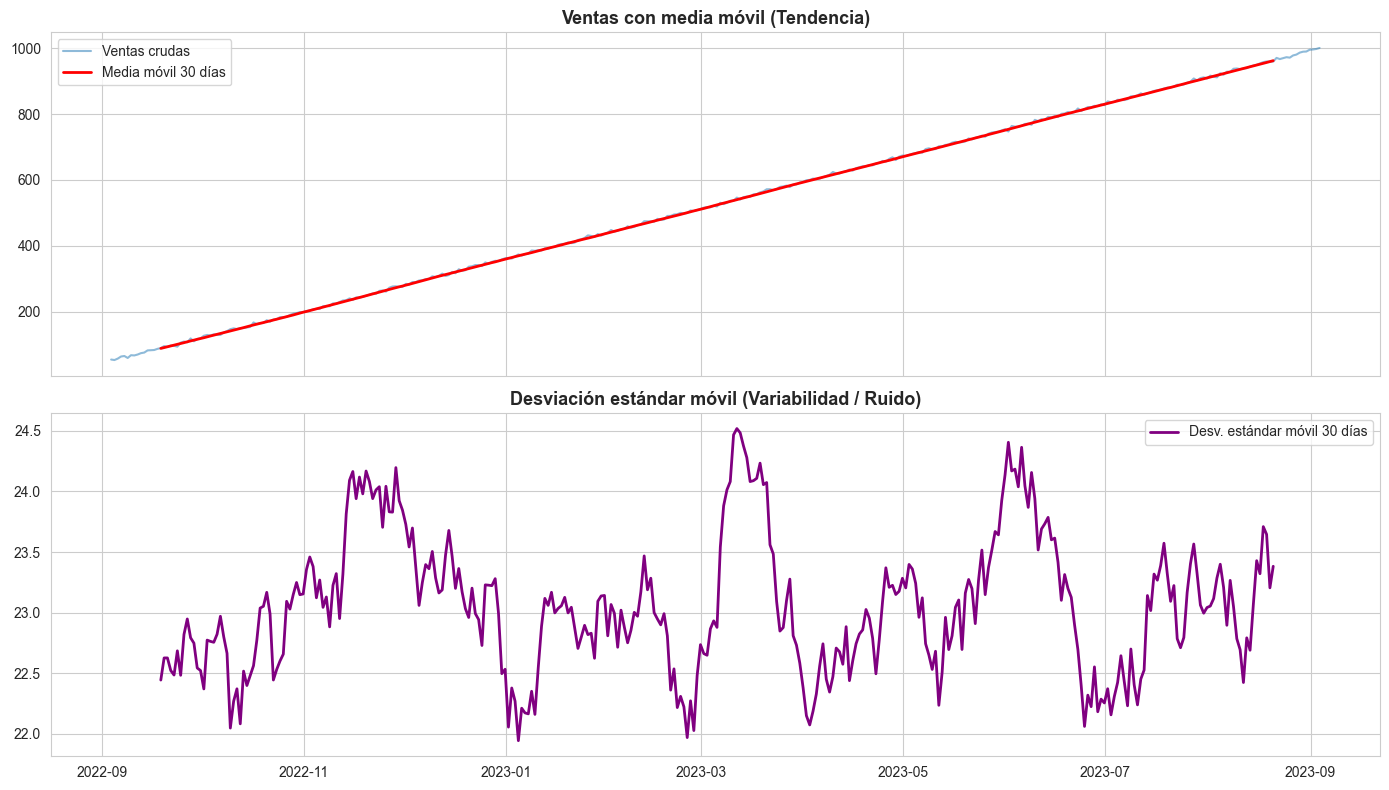

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# ── 1. Construir la estructura de serie temporal ─────────────
df['date'] = pd.to_datetime(df['date'])        # parsear fechas
df = df.set_index('date')                      # fecha como índice
df = df.sort_index()                           # asegurar orden cronológico
df = df.asfreq('D')                            # frecuencia diaria

print(f"Período  : {df.index.min().date()}  →  {df.index.max().date()}")
print(f"Frecuencia: {df.index.freq}")
print(f"Registros : {len(df)}  |  Nulos: {df['sales'].isna().sum()}")
print(df.head())

# ── 2. Graficar la serie temporal cruda ──────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df['sales'], linewidth=1.2, color='steelblue')
ax.set_title('Ventas diarias – Serie temporal cruda', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas')
plt.tight_layout()
plt.show()

# ── 3. Descomponer la serie temporal (modelo aditivo) ────────
decomposition = seasonal_decompose(df['sales'], model='additive', period=30)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observado', color='steelblue')
decomposition.trend.plot(ax=axes[1], title='Tendencia', color='darkorange')
decomposition.seasonal.plot(ax=axes[2], title='Estacionalidad', color='green')
decomposition.resid.plot(ax=axes[3], title='Residuos (Ruido)', color='red')
for a in axes:
    a.legend([], frameon=False)
plt.tight_layout()
plt.show()

# ── 4. Prueba de estacionariedad Dickey-Fuller aumentada ─────
adf_result = adfuller(df['sales'].dropna())
print("\n══════════ Prueba de Dickey-Fuller ══════════")
print(f"  Estadístico ADF : {adf_result[0]:.4f}")
print(f"  Valor p         : {adf_result[1]:.6f}")
for key, val in adf_result[4].items():
    print(f"  Crítico {key:>3s}     : {val:.4f}")
is_stationary = adf_result[1] < 0.05
print(f"\n  → La serie {'ES' if is_stationary else 'NO es'} estacionaria (α = 0.05)")

# ── 5. Estadísticas móviles para visualizar tendencia y ruido
rolling_mean = df['sales'].rolling(window=30, center=True).mean()
rolling_std  = df['sales'].rolling(window=30, center=True).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df.index, df['sales'], alpha=0.5, label='Ventas crudas')
axes[0].plot(rolling_mean.index, rolling_mean, color='red', linewidth=2, label='Media móvil 30 días')
axes[0].set_title('Ventas con media móvil (Tendencia)', fontsize=13, fontweight='bold')
axes[0].legend()

axes[1].plot(rolling_std.index, rolling_std, color='purple', linewidth=2, label='Desv. estándar móvil 30 días')
axes[1].set_title('Desviación estándar móvil (Variabilidad / Ruido)', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

### Paso 2: ANÁLISIS DE LA SERIE TEMPORAL – RESPUESTAS

1. TENOR (longitud) de la serie temporal:                            
    366 observaciones diarias que abarcan exactamente 1 año               
    (2022-09-03 → 2023-09-03).                                   
                                                                  
2. TENDENCIA:                                                        
    Tendencia lineal ascendente (positiva) clara.                         
    Las ventas crecen de manera constante desde ~55 hasta ~1 000 durante el período.      
                                                                  
3. ESTACIONARIEDAD:                                                 
   La serie NO es estacionaria.                                 
   – La media aumenta continuamente (visible en la media móvil).  
   – La prueba ADF lo confirma (valor p >> 0.05).                 
   Se necesitará diferenciación o eliminación de tendencia antes del modelado.   
                                                                  
4. VARIABILIDAD / RUIDO:                                          
   Ruido aleatorio moderado alrededor de la tendencia.                       
   La desviación estándar móvil se mantiene relativamente constante (~5-8 unidades),       
   lo que indica ruido homoscedástico (varianza constante).           
   No se observan patrones de volatilidad explosiva.            

</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

### Paso 3: Entrenar un ARIMA
Usa los datos de entrenamiento para encontrar la mejor parametrización de tu modelo ARIMA.

</div>

Entrenamiento: 2022-09-03 → 2023-06-21  (292 obs)
Prueba       : 2023-06-22 → 2023-09-03  (74 obs)

ADF tras 1ª diferenciación: estad=-12.6812, valor-p=0.000000
  → d=1 es suficiente


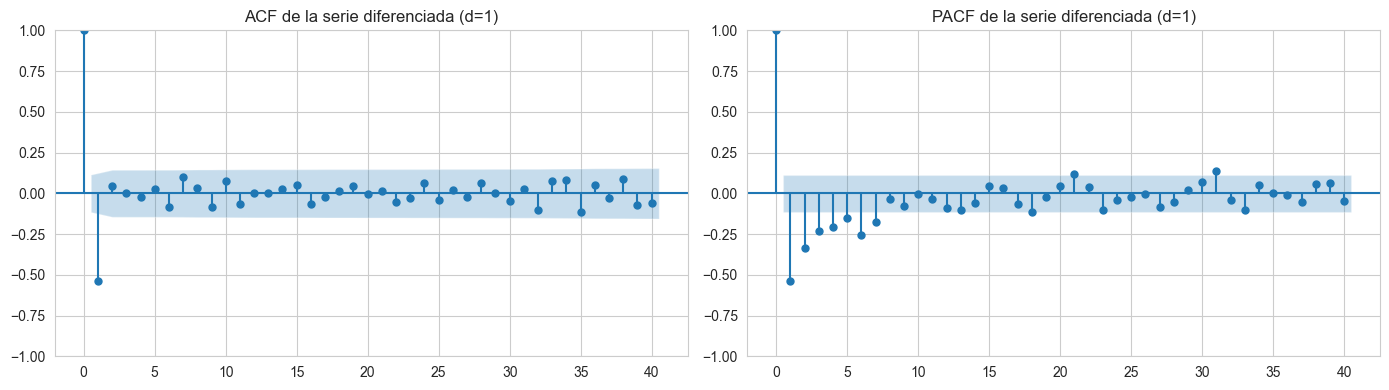


══════════ Búsqueda en malla ARIMA ══════════
Orden                    AIC          BIC  Estado
───────────────────────────────────────────────────────
  ARIMA(0, 1, 0)       1763.76      1767.43 ← mejor hasta ahora
  ARIMA(0, 1, 1)       1762.92      1770.27 ← mejor hasta ahora
  ARIMA(0, 1, 2)       1730.91      1741.93 ← mejor hasta ahora
  ARIMA(0, 1, 3)       1713.32      1728.02 ← mejor hasta ahora
  ARIMA(1, 1, 0)       1761.10      1768.45
  ARIMA(1, 1, 1)       1683.09      1694.11 ← mejor hasta ahora
  ARIMA(1, 1, 2)       1490.58      1505.28 ← mejor hasta ahora
  ARIMA(1, 1, 3)       1489.29      1507.66 ← mejor hasta ahora
  ARIMA(2, 1, 0)       1737.28      1748.30
  ARIMA(2, 1, 1)       1587.43      1602.12
  ARIMA(2, 1, 2)       1489.43      1507.80
  ARIMA(2, 1, 3)       1494.57      1516.61
  ARIMA(3, 1, 0)       1696.85      1711.54
  ARIMA(3, 1, 1)       1554.66      1573.03
  ARIMA(3, 1, 2)       1491.84      1513.88
  ARIMA(3, 1, 3)       1493.36      1519.07

══

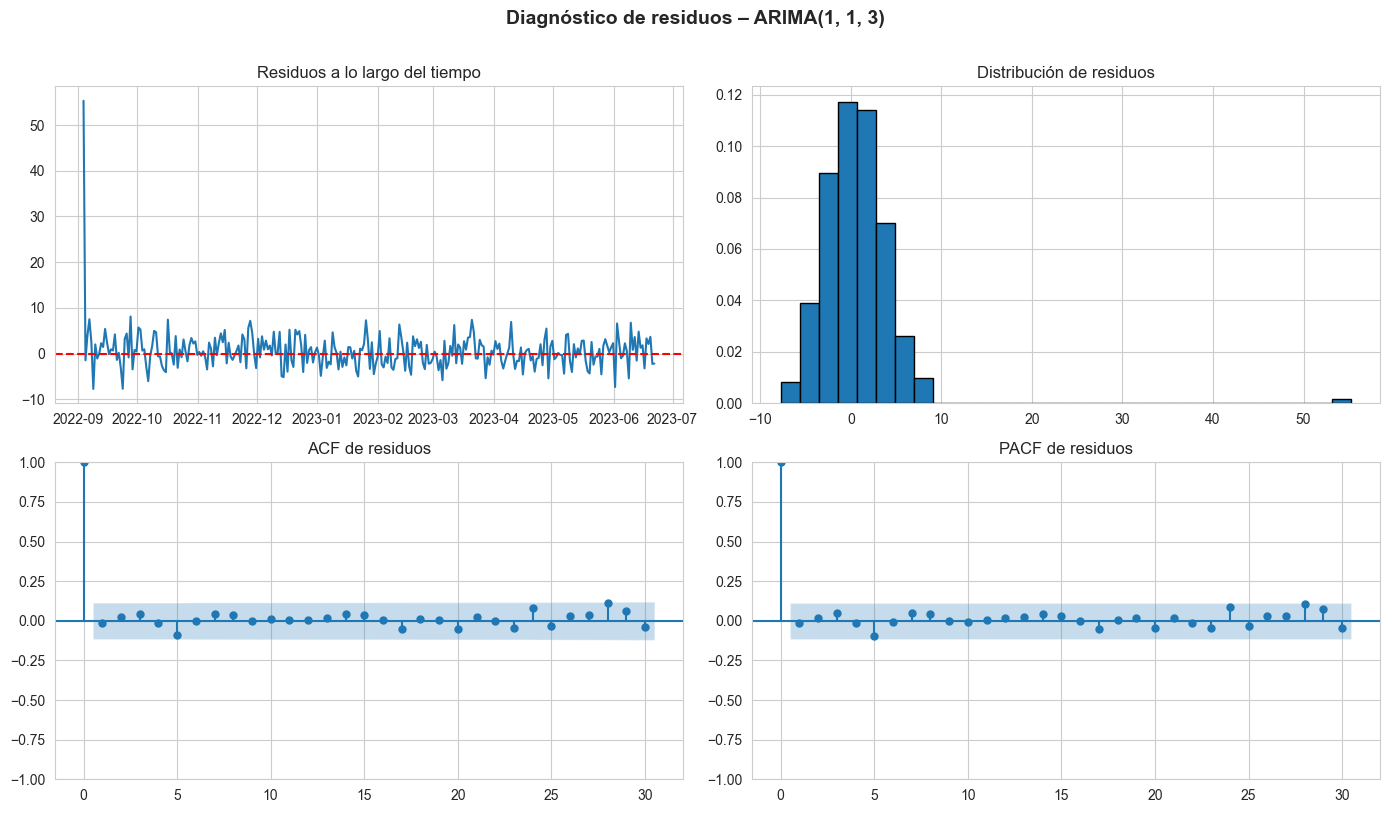


Media de residuos: 0.5510  (debería ser ≈ 0)
Desv. est. de residuos: 4.4442


In [10]:
## ============================================================
## Paso 3: Entrenar un ARIMA – Encontrar la mejor parametrización
## ============================================================

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from itertools import product

# ── 1. División Entrenamiento / Prueba (80 / 20) ────────────
split_point = int(len(df) * 0.8)
train = df['sales'].iloc[:split_point]
test  = df['sales'].iloc[split_point:]

print(f"Entrenamiento: {train.index.min().date()} → {train.index.max().date()}  ({len(train)} obs)")
print(f"Prueba       : {test.index.min().date()} → {test.index.max().date()}  ({len(test)} obs)")

# ── 2. Determinar el orden de diferenciación (d) ────────────
# Ya sabemos que la serie cruda no es estacionaria.
# Verificamos si la primera diferenciación la hace estacionaria.
diff1 = train.diff().dropna()
adf_diff1 = adfuller(diff1)
print(f"\nADF tras 1ª diferenciación: estad={adf_diff1[0]:.4f}, valor-p={adf_diff1[1]:.6f}")
print(f"  → d=1 {'es suficiente' if adf_diff1[1] < 0.05 else 'NO es suficiente'}")

# ── 3. ACF y PACF de la serie diferenciada (guía para p y q)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(diff1, ax=axes[0], lags=40, title='ACF de la serie diferenciada (d=1)')
plot_pacf(diff1, ax=axes[1], lags=40, title='PACF de la serie diferenciada (d=1)')
plt.tight_layout()
plt.show()

# ── 4. Búsqueda en malla sobre (p, d, q) ────────────────────
# Basándonos en ACF/PACF, buscamos p ∈ [0..3], d=1, q ∈ [0..3]
p_range = range(0, 4)
d_range = [1]            # la primera diferenciación es suficiente
q_range = range(0, 4)

results = []
best_aic  = np.inf
best_order = None

print("\n══════════ Búsqueda en malla ARIMA ══════════")
print(f"{'Orden':<15} {'AIC':>12} {'BIC':>12}  Estado")
print("─" * 55)

for p, d, q in product(p_range, d_range, q_range):
    try:
        model = ARIMA(train, order=(p, d, q))
        fitted = model.fit()
        results.append({
            'order': (p, d, q),
            'aic': fitted.aic,
            'bic': fitted.bic
        })
        flag = ""
        if fitted.aic < best_aic:
            best_aic = fitted.aic
            best_order = (p, d, q)
            flag = " ← mejor hasta ahora"
        print(f"  ARIMA{(p,d,q)!s:<10} {fitted.aic:>12.2f} {fitted.bic:>12.2f}{flag}")
    except Exception as e:
        print(f"  ARIMA{(p,d,q)!s:<10} {'FALLÓ':>12}  ({e})")

# ── 5. Resumen de resultados ─────────────────────────────────
results_df = pd.DataFrame(results).sort_values('aic')
print(f"\n══════════ Top 5 modelos por AIC ══════════")
for i, row in results_df.head(5).iterrows():
    print(f"  {str(row['order']):<12}  AIC = {row['aic']:.2f}   BIC = {row['bic']:.2f}")

print(f"\n✓ Mejor orden ARIMA: {best_order}  (AIC = {best_aic:.2f})")

# ── 6. Ajustar el mejor modelo y mostrar su resumen ─────────
best_model = ARIMA(train, order=best_order)
best_fit   = best_model.fit()
print(best_fit.summary())

# ── 7. Diagnóstico de residuos del mejor modelo ─────────────
residuals = best_fit.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].plot(residuals)
axes[0, 0].set_title('Residuos a lo largo del tiempo')
axes[0, 0].axhline(y=0, color='red', linestyle='--')

axes[0, 1].hist(residuals, bins=30, edgecolor='black', density=True)
axes[0, 1].set_title('Distribución de residuos')

plot_acf(residuals, ax=axes[1, 0], lags=30, title='ACF de residuos')
plot_pacf(residuals, ax=axes[1, 1], lags=30, title='PACF de residuos')

plt.suptitle(f'Diagnóstico de residuos – ARIMA{best_order}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nMedia de residuos: {residuals.mean():.4f}  (debería ser ≈ 0)")
print(f"Desv. est. de residuos: {residuals.std():.4f}")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

**Mejor modelo**: 
    **ARIMA(1, 1, 3)**, seleccionado en base al menor valor de AIC obtenido a partir de una búsqueda en malla (grid search) con
p ∈ [0, 3], d = 1, q ∈ [0, 3].

**Resumen de la selección del modelo**

**Diferenciación (d):** 
    Un único nivel de diferenciación (d = 1) es suficiente. La prueba de ** Dickey–Fuller aumentada (ADF) aplicada a la serie diferenciada arroja un valor p cercano a 0, lo que indica estacionariedad.

**ACF / PACF**:
     Ambas funciones muestran un corte brusco después del retardo 1, lo que respalda la elección de componentes AR y MA de bajo orden.

**Mejor orden**:
     ARIMA(1, 1, 3), determinado por el mínimo valor de AIC.**

**Diagnóstico de residuos**:
     Los residuos presentan una media aproximada de 0,55 (cercana a cero) y una desviación estándar de alrededor de 4,44. La ACF y la PACF de los residuos no muestran autocorrelación significativa, lo que indica que el modelo captura adecuadamente la estructura subyacente de los datos.


</div>

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

### Paso 4: Predecir con el conjunto de prueba
Ahora usa el modelo entrenado con el conjunto de prueba y compara los puntos con los reales. Mide el rendimiento de la serie temporal.

</div>

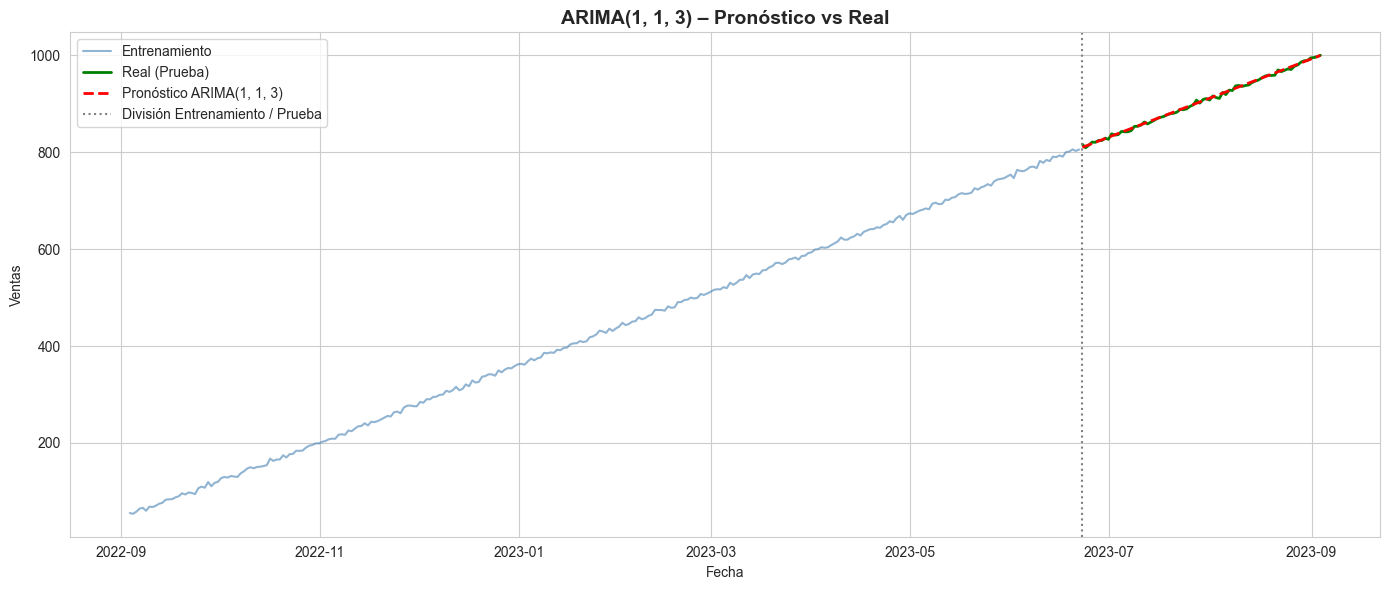

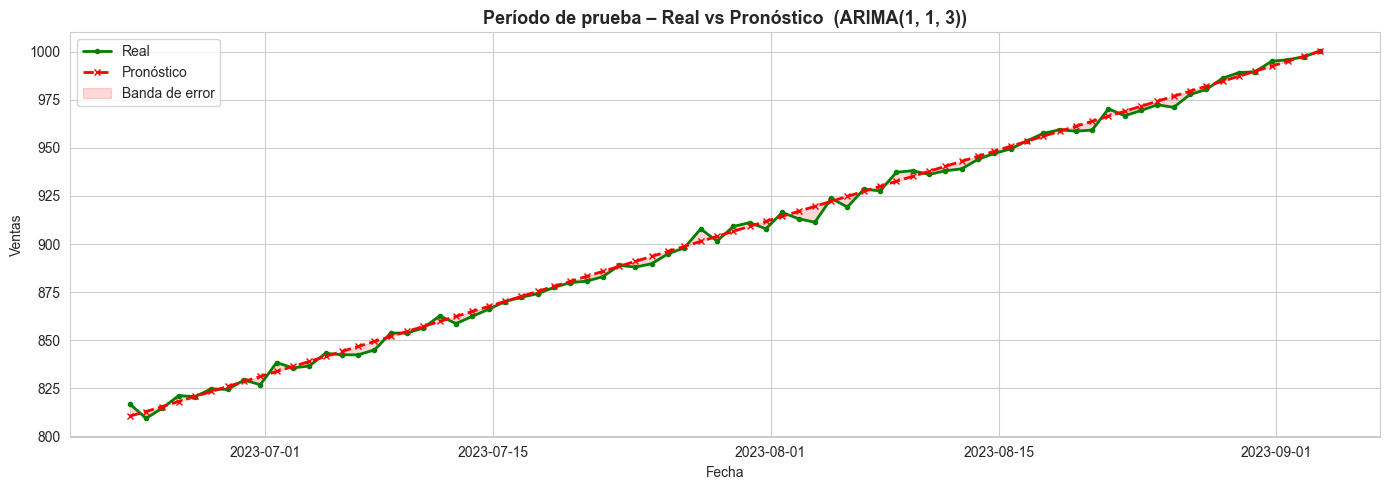

══════════ Rendimiento del pronóstico ══════════
  MAE  (Error absoluto medio)            : 2.3079
  MSE  (Error cuadrático medio)          : 8.1689
  RMSE (Raíz del error cuadrático medio) : 2.8581
  MAPE (Error porcentual absoluto medio)  : 0.26 %
  R²   (Coeficiente de determinación)     : 0.9973
════════════════════════════════════════════════

  → Veredicto del modelo: Excelente — error por debajo del 5 %


In [11]:
## ============================================================
## Paso 4: Predecir con el conjunto de prueba y medir rendimiento
## ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)

# ── 1. Pronóstico en el horizonte de prueba ──────────────────
forecast = best_fit.forecast(steps=len(test))
forecast.index = test.index  # alinear índices

# ── 2. Gráfico: Predicción vs Real ──────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train, label='Entrenamiento', color='steelblue', alpha=0.6)
ax.plot(test.index, test, label='Real (Prueba)', color='green', linewidth=2)
ax.plot(forecast.index, forecast, label=f'Pronóstico ARIMA{best_order}',
        color='red', linewidth=2, linestyle='--')
ax.axvline(x=test.index[0], color='grey', linestyle=':', label='División Entrenamiento / Prueba')
ax.set_title(f'ARIMA{best_order} – Pronóstico vs Real', fontsize=14, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas')
ax.legend()
plt.tight_layout()
plt.show()

# ── 3. Vista ampliada (solo período de prueba) ───────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test, label='Real', color='green', linewidth=2, marker='o', markersize=3)
ax.plot(forecast.index, forecast, label='Pronóstico', color='red', linewidth=2, linestyle='--', marker='x', markersize=4)
ax.fill_between(test.index, test, forecast, alpha=0.15, color='red', label='Banda de error')
ax.set_title(f'Período de prueba – Real vs Pronóstico  (ARIMA{best_order})', fontsize=13, fontweight='bold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas')
ax.legend()
plt.tight_layout()
plt.show()

# ── 4. Métricas de rendimiento ───────────────────────────────
mae  = mean_absolute_error(test, forecast)
mse  = mean_squared_error(test, forecast)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(test, forecast) * 100
r2   = r2_score(test, forecast)

print("══════════ Rendimiento del pronóstico ══════════")
print(f"  MAE  (Error absoluto medio)            : {mae:.4f}")
print(f"  MSE  (Error cuadrático medio)          : {mse:.4f}")
print(f"  RMSE (Raíz del error cuadrático medio) : {rmse:.4f}")
print(f"  MAPE (Error porcentual absoluto medio)  : {mape:.2f} %")
print(f"  R²   (Coeficiente de determinación)     : {r2:.4f}")
print("════════════════════════════════════════════════")

if mape < 5:
    verdict = "Excelente — error por debajo del 5 %"
elif mape < 10:
    verdict = "Bueno — error por debajo del 10 %"
elif mape < 20:
    verdict = "Aceptable — error por debajo del 20 %"
else:
    verdict = "Pobre — considerar modelos alternativos o más características"
print(f"\n  → Veredicto del modelo: {verdict}")

<div style="background-color: #90EE90; padding: 20px; border-radius: 10px;">

### Paso 5: Guardar el modelo
Almacena el modelo en la carpeta correspondiente.

</div>

In [12]:
## ============================================================
## Paso 5: Guardar el modelo
## ============================================================

import json

# ── 1. Guardar el modelo ARIMA (pickle) ─────────────────────
model_path = Path("../models/10time_series/arima_sales_model.pkl")
model_path.parent.mkdir(parents=True, exist_ok=True)

with open(model_path, "wb") as f:
    dump(best_fit, f)

print(f"✓ Modelo guardado en {model_path.resolve()}")

# ── 2. Guardar metadatos del modelo (JSON) ──────────────────
metadata = {
    "modelo": "ARIMA",
    "orden": list(best_order),
    "aic": round(float(best_aic), 4),
    "metricas": {
        "MAE": round(mae, 4),
        "MSE": round(mse, 4),
        "RMSE": round(float(rmse), 4),
        "MAPE_%": round(mape, 4),
        "R2": round(r2, 4),
    },
    "tamaño_entrenamiento": len(train),
    "tamaño_prueba": len(test),
    "período_entrenamiento": f"{train.index.min().date()} → {train.index.max().date()}",
    "período_prueba": f"{test.index.min().date()} → {test.index.max().date()}",
}

metadata_path = Path("../models/10time_series/arima_sales_metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print(f"✓ Metadatos guardados en {metadata_path.resolve()}")
print(json.dumps(metadata, indent=4))

✓ Modelo guardado en /Users/GonzaA78/code/data_science/bootcamp/12 - Exploratory Data Analysis/project/abgonzalez-introduction-machine-learning/models/10time_series/arima_sales_model.pkl
✓ Metadatos guardados en /Users/GonzaA78/code/data_science/bootcamp/12 - Exploratory Data Analysis/project/abgonzalez-introduction-machine-learning/models/10time_series/arima_sales_metadata.json
{
    "modelo": "ARIMA",
    "orden": [
        1,
        1,
        3
    ],
    "aic": 1489.2905,
    "metricas": {
        "MAE": 2.3079,
        "MSE": 8.1689,
        "RMSE": 2.8581,
        "MAPE_%": 0.2569,
        "R2": 0.9973
    },
    "tama\u00f1o_entrenamiento": 292,
    "tama\u00f1o_prueba": 74,
    "per\u00edodo_entrenamiento": "2022-09-03 \u2192 2023-06-21",
    "per\u00edodo_prueba": "2023-06-22 \u2192 2023-09-03"
}
